In [ ]:
import sys, os
project_root = r"C:/Users/Asia/Desktop/mocadr/MoviesRecommendations"
sys.path.insert(0, project_root)

from modules.train import train
from modules.predict import predict
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from collections import defaultdict

df_true = pd.read_csv("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test_with_ratings.csv")

In [ ]:
Z_nmf, u_nmf, m_nmf, rmse_nmf = train("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/ratings.csv", "NMF")

preds_nmf = predict(
    "C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test.csv",
    {"Z_approx": Z_nmf, "user_map": u_nmf, "movie_map": m_nmf}
)

mse_nmf = mean_squared_error(df_true["rating"], preds_nmf["rating"])
test_rmse_nmf = np.sqrt(mse_nmf)

print(f"RMSE: {test_rmse_nmf:.4f}")

plt.plot(rmse_nmf.keys(), rmse_nmf.values())

plt.xlabel("r")
plt.ylabel("RMSE")
plt.title("RMSE vs. rank r for NMF")

plt.show()

Output()

Best r=13 with RMSE = 0.9516
RMSE: 0.7566


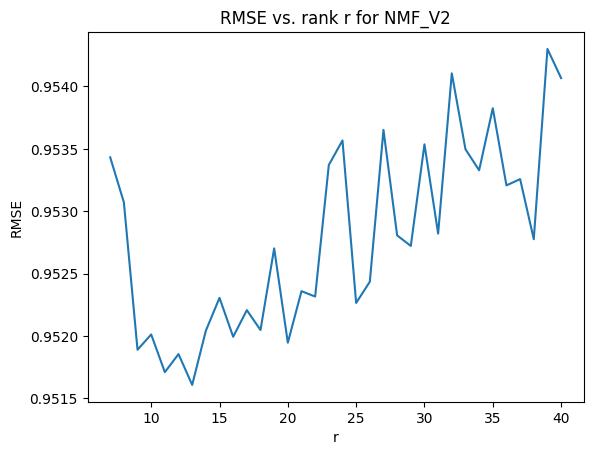

In [2]:
Z_nmf_v2, u_nmf_v2, m_nmf_v2, rmse_nmf_v2 = train("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/ratings.csv", "NMF_V2")

preds_nmf_v2 = predict(
    "C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test.csv",
    {"Z_approx": Z_nmf_v2, "user_map": u_nmf_v2, "movie_map": m_nmf_v2}
)

mse_nmf_v2 = mean_squared_error(df_true["rating"], preds_nmf_v2["rating"])
test_rmse_nmf_v2 = np.sqrt(mse_nmf_v2)

print(f"RMSE: {test_rmse_nmf_v2:.4f}")

plt.plot(rmse_nmf_v2.keys(), rmse_nmf_v2.values())

plt.xlabel("r")
plt.ylabel("RMSE")
plt.title("RMSE vs. rank r for NMF_V2")

plt.show()

Output()

Best r=1 and lambda=0.5 with RMSE = 0.9042
RMSE: 0.7969


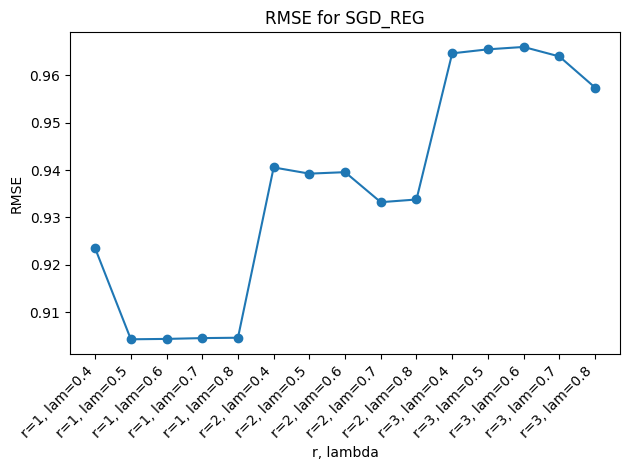

In [ ]:
Z_SGD_reg, u_SGD_reg, m_SGD_reg, rmse_SGD_reg = train("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/ratings.csv", "SGD_REG")

preds_SGD_reg = predict(
    "C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test.csv",
    {"Z_approx": Z_SGD_reg, "user_map": u_SGD_reg, "movie_map": m_SGD_reg}
)

mse_SGD_reg = mean_squared_error(df_true["rating"], preds_SGD_reg["rating"])
test_rmse_SGD_reg = np.sqrt(mse_SGD_reg)

print(f"RMSE: {test_rmse_SGD_reg:.4f}")

grouped = defaultdict(list)

for (r, lam), rmse in rmse_SGD_reg.items():
    grouped[r].append((lam, rmse))

for r, points in grouped.items():
    points = sorted(points, key=lambda x: x[0])  # sort by lambda
    lams = [str(p[0]) for p in points]
    rmses = [p[1] for p in points]
    plt.plot(lams, rmses, marker='o', label=f"r={r}")

plt.xlabel("lambda")
plt.ylabel("RMSE")
plt.title("RMSE for SGD_REG")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# type of mask = Z > 0
# type of row

In [ ]:
Z_svd2_v2, u_svd2_v2, m_svd2_v2, rmse_svd2_v2 = train("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/ratings.csv", "SVD2_V2")

preds_svd2_v2 = predict(
    "C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test.csv",
    {"Z_approx": Z_svd2_v2, "user_map": u_svd2_v2, "movie_map": m_svd2_v2}
)

mse_svd2_v2 = mean_squared_error(df_true["rating"], preds_svd2_v2["rating"])
test_rmse_svd2_v2 = np.sqrt(mse_svd2_v2)

print(f"RMSE: {test_rmse_svd2_v2:.4f}")

plt.plot(rmse_svd2_v2.keys(), rmse_svd2_v2.values())

plt.xlabel("r")
plt.ylabel("RMSE")
plt.title("RMSE vs. rank r for SVD_V2")

plt.show()

Output()

Best r=2 with RMSE = 0.9327


NameError: name 'm_nmf_v2' is not defined

RMSE: 0.7348


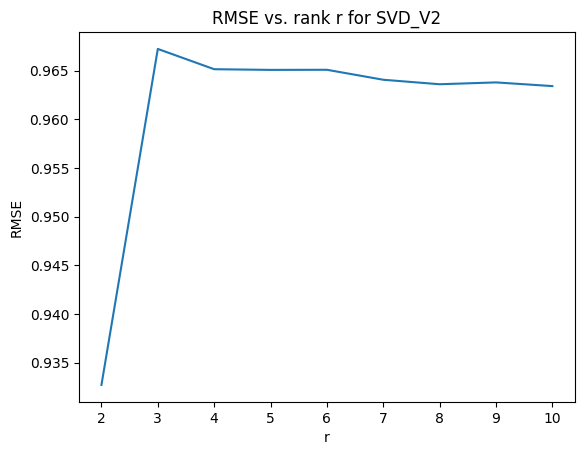

In [ ]:
preds_svd2_v2 = predict(
    "C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test.csv",
    {"Z_approx": Z_svd2_v2, "user_map": u_svd2_v2, "movie_map": m_svd2_v2}
)

mse_svd2_v2 = mean_squared_error(df_true["rating"], preds_svd2_v2["rating"])
test_rmse_svd2_v2 = np.sqrt(mse_svd2_v2)

print(f"RMSE: {test_rmse_svd2_v2:.4f}")

plt.plot(rmse_svd2_v2.keys(), rmse_svd2_v2.values())

plt.xlabel("r")
plt.ylabel("RMSE")
plt.title("RMSE vs. rank r for SVD2_V2")

plt.show()